In [99]:
from dotenv import load_dotenv
import os 
import pandas as pd
import requests
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np

load_dotenv()

API_KEY = os.getenv('FMP_API_KEY')
API_BASE = "https://financialmodelingprep.com/stable"

SESSION = requests.Session()
SESSION.headers.update({"Accept-Encoding": "gzip, deflate"}) 

TICKER = "AAPL"
DATE_START = pd.to_datetime("2016-01-01").date().isoformat()
DATE_END   = dt.datetime.now().date().isoformat()

In [100]:
def fmp_get(
        endpoint,
        params, 

):
    params={
        **params,
        "apikey": API_KEY,
    }
    url = f"{API_BASE}/{endpoint}"
    r = SESSION.get(url, params=params)
    return r.json()

In [101]:
def get_prices(
        ticker,
        start, 
        end
):
    data = fmp_get(
        endpoint="historical-price-eod/full",
        params={
            "symbol": ticker,
            "from": start,
            "to": end
        }
    )

    df = pd.DataFrame(data).sort_values('date').reset_index(drop=True)
    return df

In [102]:
def add_strategy(df):
    df['Strategy'] = 0
    df['Strategy'] = np.where(
        df['close'] < df['vwap'], 3, 
        np.where(df['close'] > df['vwap'], -3, 0)
        )
    
    df['Strategy'] = df['Strategy'].shift(1)
    
    return df

def test_strategy(df):

    df['Asset_Returns'] = (1 + df['close'].pct_change()).cumprod() - 1
    df['Strategy_Returns'] = (1 + df['close'].pct_change() * df['Strategy']).cumprod() - 1

    # plot the strategy returns
    plt.figure()
    plt.plot(df['Asset_Returns'])
    plt.plot(df['Strategy_Returns'])
    plt.legend([f'{TICKER} Cumulative', 'Strategy Cumulative'])
    plt.title(F'VWAP Strategy vs {TICKER}');

    return df

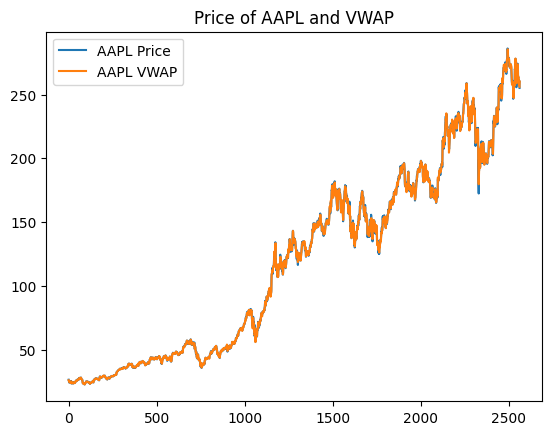

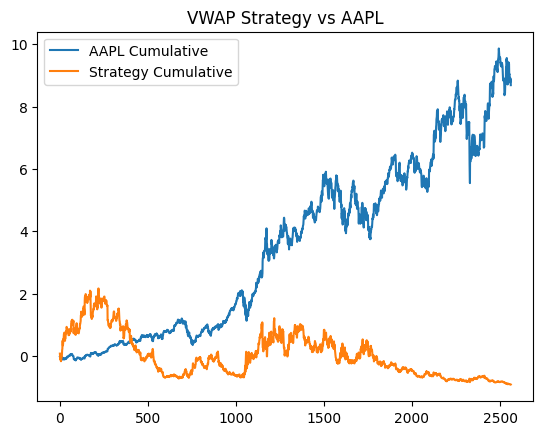

In [103]:
def main():
    df = get_prices(
        ticker=TICKER,
        start=DATE_START,
        end=DATE_END
    )
    plt.plot(df.close)
    plt.plot(df.vwap)
    plt.title(f"Price of {TICKER} and VWAP")
    plt.legend([
        f'{TICKER} Price',
        f'{TICKER} VWAP'
    ])
    
    df = add_strategy(df)
    df = test_strategy(df)

    return df

df = main()